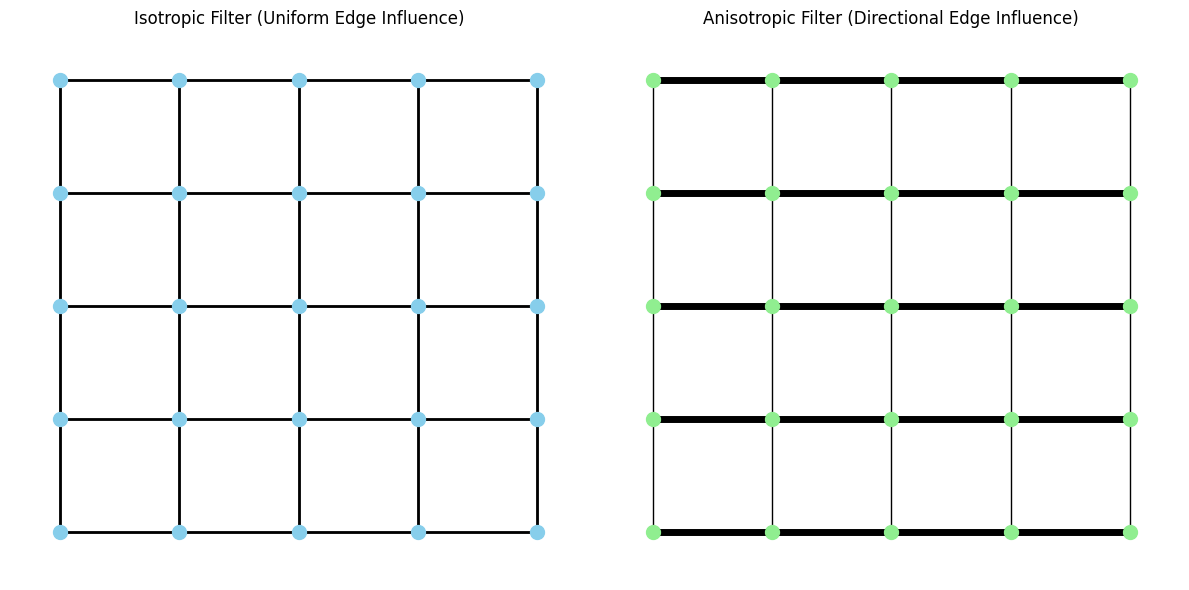

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create a toy graph
G = nx.grid_2d_graph(5, 5)  # 5x5 grid
pos = dict((n, n) for n in G.nodes())  # positions for plotting

# Assign isotropic weights (uniform)
for u, v in G.edges():
    G[u][v]['weight_iso'] = 1.0

for u, v in G.edges():
    if abs(u[0] - v[0]) == 1:  # horizontal
        G[u][v]['weight_aniso'] = 5.0
    else:  # vertical
        G[u][v]['weight_aniso'] = 0.5

# Draw graphs again with more visible differences
plt.figure(figsize=(12, 6))

# Isotropic
plt.subplot(1, 2, 1)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight_iso').items())
nx.draw(G, pos, with_labels=False, node_color='skyblue', node_size=100)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=2)
plt.title("Isotropic Filter (Uniform Edge Influence)")

# Anisotropic
plt.subplot(1, 2, 2)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight_aniso').items())
nx.draw(G, pos, with_labels=False, node_color='lightgreen', node_size=100)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w for w in weights])
plt.title("Anisotropic Filter (Directional Edge Influence)")

plt.tight_layout()
plt.show()